# 🤖 __Class 6:__ Machine Learning - Classification model: Logistic Regression: 📊
---

#### 📈 __Mathematical Foundation: Logistic Regression Overview__ 🧠

Logistic Regression is a fundamental statistical model used for **Binary Classification**. Unlike Linear Regression, which predicts continuous values, Logistic Regression predicts the **probability** of a categorical outcome (e.g., "Will the customer churn? Yes or No").

#### ⚙️ How it Works:
The model calculates a linear combination of input features ($X$) and then applies the **Sigmoid Function** (also known as the Logistic Function) to "squash" the result into a range between **0 and 1**, which we interpret as a probability:

$$P(y=1 | X) = \sigma(z) = \frac{1}{1 + e^{-z}}$$

Where $z$ is the linear predictor:
$$z = \beta_0 + \beta_1 X_1 + \beta_2 X_2 + \dots + \beta_n X_n$$



---

#### 🎯 Key Concepts for this Lab:

* **Log-Odds & Coefficients:** The coefficients ($\beta$) represent the change in the **log-odds** of the outcome for a one-unit increase in the predictor.
    * If $\beta_{Age} > 0$: An increase in age **increases** the probability of Churn.
    * If $\beta_{Active} < 0$: Being an active member **decreases** the probability of Churn.

* **The Decision Threshold:** By default, we use a threshold of **0.5**.
    $$\hat{y} = \begin{cases} 1 & \text{if } P(y=1|X) \geq 0.5 \\ 0 & \text{if } P(y=1|X) < 0.5 \end{cases}$$
    *In Banking, we often lower this threshold to prioritize **Recall** (catching more leavers).*

* **Maximum Likelihood Estimation (MLE):** Unlike OLS in linear regression, Logistic Regression uses **MLE** to find the $\beta$ values that maximize the likelihood of observing the actual classes (0 or 1) present in our training data.

---

#### 📊 Evaluation Roadmap:
In this notebook, we move beyond simple Accuracy to evaluate model robustness:
1.  **Confusion Matrix:** Identifying Type I (False Positive) and Type II (False Negative) errors.
2.  **ROC Curve & AUC:** Measuring the model's global ability to separate classes across all possible thresholds.
3.  **Statistical Significance:** Using **p-values** ($P > |z|$) to verify which customer attributes are true drivers of churn.

### 📤 __MAIN IMPORTS__⚙️
---

In [1]:
import pandas as pd
import numpy as np
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import (confusion_matrix, ConfusionMatrixDisplay,classification_report, roc_curve, auc)

### 💾 __Reading data__
---

In [11]:
#GENERATING DATASET.
path = "https://media.githubusercontent.com/media/hector1994/e_commerce_funnel_data_generator/refs/heads/master/Bank_data.csv"
df   = pd.read_csv(path)
df   = df.drop(columns=['Unnamed: 0'], axis = 1)

In [12]:
#QUICK CHECK.
df.head()

,Age,Balance,IsActiveMember,NumProducts,Exited
0,44.967142,70990.331549,0,3,0
1,38.617357,63869.505244,0,3,1
2,46.476885,50894.455549,0,2,1
3,55.230299,40295.948334,0,2,1
4,37.658466,60473.349704,1,1,0


#### 🗺️ __Bank Churn Journey: Model Variable Definitions__ 🔍
#### 🛠️ Data Dictionary (Features & Target)

| ID | Variable | Technical Description | Classification |
| :--- | :--- | :--- | :--- |
| **0** | <font color="#7abaff">`Age`</font> | Chronological age of the customer. Demographic risk factor. | <font color="#7abaff">Demographics</font> |
| **1** | <font color="#7abaff">`Balance`</font> | Total account balance. Indicator of customer wealth/equity. | <font color="#7abaff">Financial</font> |
| **2** | <font color="#ffd43b">`IsActiveMember`</font> | Binary flag (0/1). User interaction with App or Branch. | <font color="#ffd43b">Interaction</font> |
| **3** | <font color="#ffd43b">`NumProducts`</font> | Number of active bank products (Accounts, Loans, etc.). | <font color="#ffd43b">Engagement</font> |
| **4** | <font color="#ff6b6b">`Exited`</font> | **Target Variable.** 1 if the customer left, 0 if they stayed. | <font color="#ff6b6b">Final State</font> |
| **5** | <font color="#8ce99a">`Prob_Churn`</font> | **Model Output.** Estimated probability of leaving (0 to 1). | <font color="#8ce99a">Prediction</font> |

---

### 🔎 __Let's take a quick view to our data__
---

In [22]:
#LET'S CHECK THE REGISTERS
df.head()

,Age,Balance,IsActiveMember,NumProducts,Exited
0,44.967142,70990.331549,0,3,0
1,38.617357,63869.505244,0,3,1
2,46.476885,50894.455549,0,2,1
3,55.230299,40295.948334,0,2,1
4,37.658466,60473.349704,1,1,0


In [26]:
#METHODS describe() - info()
print(df.describe())
print("\n")
print(df.info())

               Age       Balance  IsActiveMember  NumProducts       Exited
count  1000.000000   1000.000000     1000.000000   1000.00000  1000.000000
mean     40.223495  51062.543559        0.503000      2.03300     0.651000
std       9.713912  14961.815658        0.500241      0.81889     0.476892
min      18.000000   5894.170480        0.000000      1.00000     0.000000
25%      33.524097  40906.374665        0.000000      1.00000     0.000000
50%      40.253006  50946.156985        1.000000      2.00000     1.000000
75%      46.479439  60933.232655        1.000000      3.00000     1.000000
max      78.527315  97896.613518        1.000000      3.00000     1.000000


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             1000 non-null   float64
 1   Balance         1000 non-null   float64
 2   IsActiveMember  1000 non-null   i

In [28]:
#LET'S CHECK THE LABELS DISTRIBUTIONS
100*df['Exited'].value_counts(normalize = True).reset_index()

,Exited,proportion
0,100,65.1
1,0,34.9


### 📚 __Let's prepare our data__
---

In [13]:
#TRAIN-TEST SPLIT.
df_train, df_test = train_test_split(df, test_size=0.20, random_state=42)
print(f"Registros Entrenamiento: {len(df_train)} | Registros Test: {len(df_test)}")

Registros Entrenamiento: 800 | Registros Test: 200


### 🚀 __Let's fit the model__
---

In [14]:
# LOGISTIC REGRESSION MODEL.
model = smf.logit('Exited ~ Age + IsActiveMember + Balance + NumProducts', data=df_train).fit()

# SUMMARY.
print(model.summary())

Optimization terminated successfully.
         Current function value: 0.555758
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:                 Exited   No. Observations:                  800
Model:                          Logit   Df Residuals:                      795
Method:                           MLE   Df Model:                            4
Date:                Sat, 04 Apr 2026   Pseudo R-squ.:                  0.1341
Time:                        07:32:32   Log-Likelihood:                -444.61
converged:                       True   LL-Null:                       -513.49
Covariance Type:            nonrobust   LLR p-value:                 8.496e-29
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept         -1.6144      0.513     -3.146      0.002      -2.620      -0.609
Age              

### 📊 __Performance metrics__
---

In [21]:
# --- EVALUATION ON TEST SET (DATA UNSEEN DURING TRAINING) ---

# 1. CALCULATE ESTIMATED PROBABILITIES USING THE TEST DATASET
# THE .PREDICT() METHOD RETURNS THE OUTPUT OF THE SIGMOID FUNCTION (VALUES BETWEEN 0 AND 1)
df_test['Prob_Churn'] = model.predict(df_test)

# 2. CONVERT PROBABILITIES INTO CLASS LABELS (0 OR 1)
# WE APPLY A 0.5 THRESHOLD: IF PROB > 0.5, THE PREDICTION IS 1 (CHURN), ELSE 0 (STAY)
df_test['Prediccion'] = (df_test['Prob_Churn'] > 0.5).astype(int)

# 3. GENERATE A COMPARATIVE TABLE TO VERIFY MODEL DECISIONS
# WE SHOW THE REAL VALUE, THE PREDICTED LABEL, AND THE CALCULATED PROBABILITY
print("\n--- RESULTS COMPARISON TABLE (FIRST 10 TEST RECORDS) ---")
print(df_test[['Exited', 'Prediccion', 'Prob_Churn']].head(20))

# 4. GENERATE THE FINAL CLASSIFICATION REPORT
# THIS INCLUDES KEY METRICS: PRECISION, RECALL, F1-SCORE, AND ACCURACY FOR THE TEST SET
print("\n--- CLASSIFICATION REPORT (TEST DATA PERFORMANCE) ---")
print(classification_report(df_test['Exited'], df_test['Prediccion']))


--- RESULTS COMPARISON TABLE (FIRST 10 TEST RECORDS) ---
     Exited  Prediccion  Prob_Churn
521       1           1    0.654124
737       1           1    0.883289
740       0           0    0.205220
660       1           1    0.684662
411       0           0    0.321341
678       1           1    0.900388
626       0           1    0.680678
513       0           1    0.650227
859       0           1    0.669462
136       1           1    0.645433
811       1           0    0.453495
76        1           1    0.810170
636       0           1    0.659794
973       0           1    0.665854
938       1           1    0.809931
899       1           0    0.418661
280       1           1    0.789888
883       1           1    0.701056
761       0           1    0.845658
319       0           1    0.516085

--- CLASSIFICATION REPORT (TEST DATA PERFORMANCE) ---
              precision    recall  f1-score   support

           0       0.68      0.36      0.47        76
           1       0.6

### 👨🏻‍💻 __Confusion Matrix + ROC curve - AUC__
---

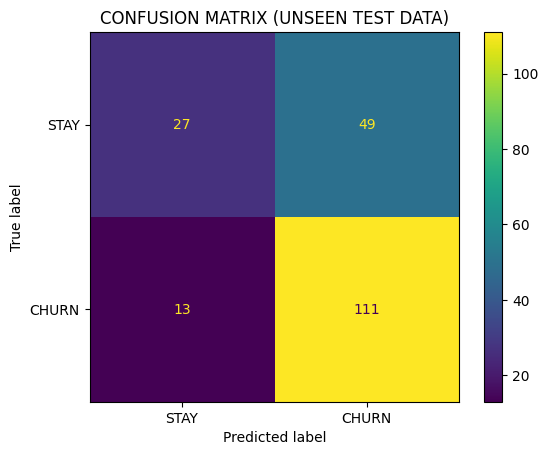

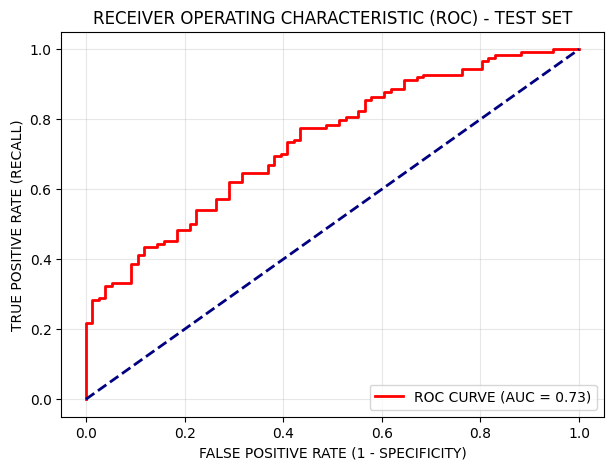

In [20]:
# --- CONFUSION MATRIX VISUALIZATION (TEST DATA) ---

# 1. GENERATE THE CONFUSION MATRIX USING REAL LABELS VS. PREDICTIONS
# THIS REVEALS TRUE POSITIVES (TP), FALSE POSITIVES (FP), FALSE NEGATIVES (FN), AND TRUE NEGATIVES (TN)
CM = confusion_matrix(df_test['Exited'], df_test['Prediccion'])
DISP = ConfusionMatrixDisplay(confusion_matrix=CM, display_labels=['STAY', 'CHURN'])

# 2. PLOT THE MATRIX TO IDENTIFY IF THE MODEL IS SKEWED TOWARDS ONE CLASS
DISP.plot(cmap='viridis')
plt.title("CONFUSION MATRIX (UNSEEN TEST DATA)")
plt.show()

# --- ROC CURVE AND AUC CALCULATION (GLOBAL PERFORMANCE) ---

# 3. CALCULATE THE FALSE POSITIVE RATE (FPR) AND TRUE POSITIVE RATE (TPR)
# WE USE THE RAW PROBABILITIES (PROB_CHURN) TO EVALUATE ALL POSSIBLE THRESHOLDS
FPR, TPR, _ = roc_curve(df_test['Exited'], df_test['Prob_Churn'])
ROC_AUC = auc(FPR, TPR)

# 4. PLOT THE ROC CURVE: THE CLOSER TO THE TOP-LEFT CORNER, THE BETTER THE MODEL
plt.figure(figsize=(7, 5))
plt.plot(FPR, TPR, color='red', lw=2, label=f'ROC CURVE (AUC = {ROC_AUC:.2f})')
plt.plot([0, 1], [0, 1], color='NAVY', lw=2, linestyle='--') # RANDOM GUESS LINE
plt.xlabel('FALSE POSITIVE RATE (1 - SPECIFICITY)')
plt.ylabel('TRUE POSITIVE RATE (RECALL)')
plt.title('RECEIVER OPERATING CHARACTERISTIC (ROC) - TEST SET')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()